# Project 2: Preparing Stock Data for Machine Learning

**Name:** OBAJE PAUL  
**Course:** MACHINE LEARNING  

## Purpose

In this project, I prepared the historical stock data from Project 1 for use in later machine-learning work. I followed the updated Project 2 instructions: clean the source data, investigate unusual observations, create the required price-based features, combine the two datasets, encode selected categorical variables, and save a final prepared dataset.

I did not build a machine-learning model in this project. The purpose here is to make the data suitable for Project 3.

## 1. Load the datasets

The two datasets are connected through the `ticker` column:

- `historical_stocks.csv` contains stock/security metadata.
- `historical_stock_prices.csv` contains daily market observations.

Because the price file is large, I use chunked processing for the full dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stocks_path = "historical_stocks.csv"
prices_path = "historical_stock_prices.csv"

stocks = pd.read_csv(stocks_path)
print("Stocks shape:", stocks.shape)

prices_sample = pd.read_csv(prices_path, nrows=200_000, low_memory=False)
print("Price review sample shape:", prices_sample.shape)
prices_sample.head()

Stocks shape: (6460, 5)
Price review sample shape: (200000, 8)


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


## 2. Clean the metadata

The updated instructions refer to an accidental `Symbol` record identified in Project 1. I removed that record before merging the metadata.

I did not treat missing sector/industry values as numerical zeros. I kept them as `UNKNOWN` so that the missing category is not confused with a real business sector.

In [3]:
stocks = stocks.loc[stocks["ticker"].astype(str).str.strip().ne("Symbol")].copy()
stocks["sector"] = stocks["sector"].fillna("UNKNOWN")
stocks["industry"] = stocks["industry"].fillna("UNKNOWN")

print("Clean metadata shape:", stocks.shape)
print("Duplicate tickers:", stocks["ticker"].duplicated().sum())
print("Missing values:")
print(stocks.isna().sum())

Clean metadata shape: (6459, 5)
Duplicate tickers: 0
Missing values:
ticker      0
exchange    0
name        0
sector      0
industry    0
dtype: int64


## 3. Load, type, sort, and validate the price data

For the full run, I process the large price file in chunks. Before feature engineering, I convert `date` to datetime and sort each chunk by `ticker` and `date`.

I also check basic price integrity. Rows with impossible positive-price relationships, such as a high below one of the day's OHLC values, are treated as invalid rather than silently corrected.

In [4]:
prices = pd.read_csv(prices_path, nrows=200_000, low_memory=False)
prices["date"] = pd.to_datetime(prices["date"], errors="coerce")

# Basic integrity checks
valid = prices[["open","close","adj_close","low","high","volume","date"]].notna().all(axis=1)
valid &= (prices[["open","close","adj_close","low","high"]] > 0).all(axis=1)
valid &= prices["volume"].ge(0)
valid &= prices["high"].ge(prices[["open","low","close"]].max(axis=1))
valid &= prices["low"].le(prices[["open","high","close"]].min(axis=1))

print("Rows failing basic integrity checks:", (~valid).sum())
prices = prices.loc[valid].copy()
prices = prices.sort_values(["ticker","date"], kind="mergesort")

Rows failing basic integrity checks: 0


## 4. Investigate unusual close and adjusted-close values

The Project 2 instructions specifically say not to assume that every unusual value is an error. In the supplied review sample, the largest close values occur for `VIAV` around March 2000.

I retained these observations because the values form a coherent historical sequence rather than appearing as isolated malformed entries, and the OHLC relationships are internally valid. I therefore treat them as unusual observations to retain, rather than deleting them simply because they are large.

Largest close values:


,ticker,date,close
34184,VIAV,2000-03-06,666.808899
34205,VIAV,2000-03-07,653.868042
34118,VIAV,2000-03-01,639.078491
34162,VIAV,2000-03-03,637.087585
34271,VIAV,2000-03-10,627.986328
34140,VIAV,2000-03-02,621.160400
34227,VIAV,2000-03-08,621.160400
34249,VIAV,2000-03-09,620.022766
36265,VIAV,2000-07-26,618.600708
36199,VIAV,2000-07-21,613.481201


Largest adjusted-close values:


,ticker,date,adj_close
34184,VIAV,2000-03-06,666.808899
34205,VIAV,2000-03-07,653.868042
34118,VIAV,2000-03-01,639.078491
34162,VIAV,2000-03-03,637.087585
34271,VIAV,2000-03-10,627.986328
34140,VIAV,2000-03-02,621.160400
34227,VIAV,2000-03-08,621.160400
34249,VIAV,2000-03-09,620.022766
36265,VIAV,2000-07-26,618.600708
36199,VIAV,2000-07-21,613.481201


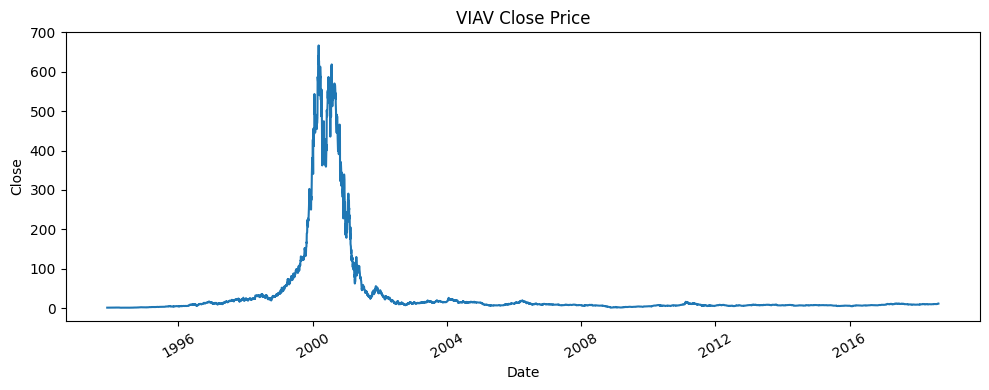

In [5]:
print("Largest close values:")
display(prices.nlargest(10, "close")[["ticker","date","close"]])

print("Largest adjusted-close values:")
display(prices.nlargest(10, "adj_close")[["ticker","date","adj_close"]])

viav = prices.loc[prices["ticker"].eq("VIAV")].sort_values("date")
plt.figure(figsize=(10,4))
plt.plot(viav["date"], viav["close"])
plt.title("VIAV Close Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Feature engineering

I created the features required by the updated instructions:

- `price_change`: current close minus the previous close.
- `daily_return`: percentage change from the previous close.
- `close_lag_1`: previous trading day's close.
- `ma_5`: five-day moving average.
- `ma_20`: twenty-day moving average.
- `volatility_20`: twenty-day rolling standard deviation of daily returns.
- `daily_range_pct`: `(high - low) / close`.

I selected daily range percentage as my additional feature because it captures the size of the daily trading range relative to the stock's price.

In [6]:
g = prices.groupby("ticker", sort=False)

prices["price_change"] = g["close"].diff()
prices["daily_return"] = g["close"].pct_change()
prices["close_lag_1"] = g["close"].shift(1)

prices["ma_5"] = (
    g["close"].rolling(5, min_periods=5)
    .mean()
    .reset_index(level=0, drop=True)
)

prices["ma_20"] = (
    g["close"].rolling(20, min_periods=20)
    .mean()
    .reset_index(level=0, drop=True)
)

prices["volatility_20"] = (
    g["daily_return"].rolling(20, min_periods=20)
    .std()
    .reset_index(level=0, drop=True)
)

prices["daily_range_pct"] = (prices["high"] - prices["low"]) / prices["close"]

prices.head(25)

,ticker,open,close,adj_close,low,high,volume,date,price_change,daily_return,close_lag_1,ma_5,ma_20,volatility_20,daily_range_pct
948,AAPL,0.513393,0.513393,0.023186,0.513393,0.515625,117258400,1980-12-12,NaN,NaN,NaN,NaN,NaN,NaN,0.004348
960,AAPL,0.488839,0.486607,0.021977,0.486607,0.488839,43971200,1980-12-15,-0.026786,-0.052174,0.513393,NaN,NaN,NaN,0.004587
968,AAPL,0.453125,0.450893,0.020364,0.450893,0.453125,26432000,1980-12-16,-0.035714,-0.073394,0.486607,NaN,NaN,NaN,0.004950
980,AAPL,0.462054,0.462054,0.020868,0.462054,0.464286,21610400,1980-12-17,0.011161,0.024752,0.450893,NaN,NaN,NaN,0.004831
988,AAPL,0.475446,0.475446,0.021473,0.475446,0.477679,18362400,1980-12-18,0.013393,0.028986,0.462054,0.477679,NaN,NaN,0.004695
1000,AAPL,0.504464,0.504464,0.022783,0.504464,0.506696,12157600,1980-12-19,0.029018,0.061033,0.475446,0.475893,NaN,NaN,0.004425
1008,AAPL,0.529018,0.529018,0.023892,0.529018,0.531250,9340800,1980-12-22,0.024554,0.048673,0.504464,0.484375,NaN,NaN,0.004219
1020,AAPL,0.551339,0.551339,0.024900,0.551339,0.553571,11737600,1980-12-23,0.022321,0.042194,0.529018,0.504464,NaN,NaN,0.004049
1028,AAPL,0.580357,0.580357,0.026211,0.580357,0.582589,12000800,1980-12-24,0.029018,0.052632,0.551339,0.528125,NaN,NaN,0.003846
1040,AAPL,0.633929,0.633929,0.028630,0.633929,0.636161,13893600,1980-12-26,0.053571,0.092308,0.580357,0.559821,NaN,NaN,0.003521


## 6. Handle expected missing values from feature engineering

The first observation for each ticker cannot have a previous-day value. Similarly, a 5-day moving average needs five observations, and a 20-day moving measure needs enough prior returns.

I do not replace these values with zero because zero would create false information. For the final modeling table, I remove rows that are missing any required engineered feature. This means the first part of each stock's history is excluded from the modeling-ready table, while the original observations remain available in the source dataset.

In [7]:
feature_cols = [
    "price_change", "daily_return", "close_lag_1",
    "ma_5", "ma_20", "volatility_20", "daily_range_pct"
]

missing_before = prices[feature_cols].isna().sum()
print(missing_before)

prices_model = prices.dropna(subset=feature_cols).copy()
print("Rows removed because of expected feature warm-up:", len(prices) - len(prices_model))

price_change         53
daily_return         53
close_lag_1          53
ma_5                212
ma_20              1007
volatility_20      1060
daily_range_pct       0
dtype: int64
Rows removed because of expected feature warm-up: 1060


## 7. Merge stock metadata

I merge `exchange`, `sector`, and `industry` using `ticker` as the key. I use a many-to-one validation so that a ticker cannot unexpectedly match multiple metadata records.

In [8]:
prices_model = prices_model.merge(
    stocks[["ticker","exchange","sector","industry"]],
    on="ticker",
    how="left",
    validate="many_to_one"
)

print("Rows after merge:", len(prices_model))
print("Duplicate ticker-date records:", prices_model.duplicated(["ticker","date"]).sum())

Rows after merge: 198940
Duplicate ticker-date records: 0


## 8. One-hot encode categorical variables

I use one-hot encoding for `exchange` and `sector`. This is preferable to assigning arbitrary numbers such as NASDAQ=1 and NYSE=2 because the numeric labels would incorrectly suggest that one category is greater than another.

I keep `industry` as descriptive metadata because it has higher cardinality and can be encoded later if it is selected for a specific model.

In [9]:
prices_model["exchange"] = prices_model["exchange"].fillna("UNKNOWN")
prices_model["sector"] = prices_model["sector"].fillna("UNKNOWN")
prices_model["industry"] = prices_model["industry"].fillna("UNKNOWN")

prices_model = pd.get_dummies(
    prices_model,
    columns=["exchange", "sector"],
    dtype="int8"
)

prices_model.head()

,ticker,open,close,adj_close,low,high,volume,date,price_change,daily_return,...,sector_CONSUMER DURABLES,sector_CONSUMER NON-DURABLES,sector_CONSUMER SERVICES,sector_ENERGY,sector_FINANCE,sector_HEALTH CARE,sector_MISCELLANEOUS,sector_PUBLIC UTILITIES,sector_TECHNOLOGY,sector_UNKNOWN
0,AAPL,0.546875,0.544643,0.024598,0.544643,0.546875,5762400,1981-01-13,-0.020089,-0.035573,...,0,0,0,0,0,0,0,0,1,0
1,AAPL,0.546875,0.546875,0.024699,0.546875,0.549107,3572800,1981-01-14,0.002232,0.004098,...,0,0,0,0,0,0,0,0,1,0
2,AAPL,0.558036,0.558036,0.025203,0.558036,0.562500,3516800,1981-01-15,0.011161,0.020408,...,0,0,0,0,0,0,0,0,1,0
3,AAPL,0.555804,0.553571,0.025001,0.553571,0.555804,3348800,1981-01-16,-0.004464,-0.008000,...,0,0,0,0,0,0,0,0,1,0
4,AAPL,0.587054,0.587054,0.026513,0.587054,0.589286,10393600,1981-01-19,0.033482,0.060484,...,0,0,0,0,0,0,0,0,1,0


## 9. Full-dataset processing pattern

Because the supplied price file is much larger than normal classroom samples, the final run should use chunks. The important point is to retain the last 20 observations for each ticker between chunks so that lag, moving-average, and volatility calculations do not restart at every chunk.

The following pattern is the version I would use for the full dataset. It writes the final file as `stock_prepared.csv`.

In [ ]:
# Full-dataset pattern
# Run this cell when the two source CSV files are available in the working directory.

CHUNK_SIZE = 2_000_000
output_path = "stock_prepared.csv"
state = pd.DataFrame()
first_write = True

for chunk in pd.read_csv(prices_path, chunksize=CHUNK_SIZE, low_memory=False):
    chunk["date"] = pd.to_datetime(chunk["date"], errors="coerce")

    # Apply the same source-data validation used above.
    valid = chunk[["open","close","adj_close","low","high","volume","date"]].notna().all(axis=1)
    valid &= (chunk[["open","close","adj_close","low","high"]] > 0).all(axis=1)
    valid &= chunk["volume"].ge(0)
    valid &= chunk["high"].ge(chunk[["open","low","close"]].max(axis=1))
    valid &= chunk["low"].le(chunk[["open","high","close"]].min(axis=1))
    chunk = chunk.loc[valid].drop_duplicates(["ticker","date"], keep="first")
    chunk = chunk.sort_values(["ticker","date"], kind="mergesort")
    chunk["_tail"] = 0

    if not state.empty:
        state["_tail"] = 1
        combined = pd.concat([state, chunk], ignore_index=True)
        combined = combined.sort_values(
            ["ticker","date","_tail"], kind="mergesort"
        )
    else:
        combined = chunk

    g = combined.groupby("ticker", sort=False)
    combined["price_change"] = g["close"].diff()
    combined["daily_return"] = g["close"].pct_change()
    combined["close_lag_1"] = g["close"].shift(1)
    combined["ma_5"] = (
        g["close"].rolling(5, min_periods=5)
        .mean().reset_index(level=0, drop=True)
    )
    combined["ma_20"] = (
        g["close"].rolling(20, min_periods=20)
        .mean().reset_index(level=0, drop=True)
    )
    combined["volatility_20"] = (
        g["daily_return"].rolling(20, min_periods=20)
        .std().reset_index(level=0, drop=True)
    )
    combined["daily_range_pct"] = (
        combined["high"] - combined["low"]
    ) / combined["close"]

    # Carry the last 20 rows for every ticker into the next chunk.
    state = combined.groupby("ticker", sort=False).tail(20).drop(columns="_tail")

    out = combined.loc[combined["_tail"].eq(0)].copy()
    out = out.dropna(subset=feature_cols)

    # Merge metadata and encode exchange/sector exactly as above.
    out = out.merge(
        stocks[["ticker","exchange","sector","industry"]],
        on="ticker", how="left", validate="many_to_one"
    )
    out["exchange"] = out["exchange"].fillna("UNKNOWN")
    out["sector"] = out["sector"].fillna("UNKNOWN")
    out["industry"] = out["industry"].fillna("UNKNOWN")
    out = pd.get_dummies(out, columns=["exchange","sector"], dtype="int8")

    out.to_csv(
        output_path,
        mode="w" if first_write else "a",
        header=first_write,
        index=False
    )
    first_write = False

print("Saved:", output_path)

## 10. Final checks

Before using the prepared data in Project 3, I check the row/column counts, data types, missing values, duplicate ticker-date combinations, and date range.

In [ ]:
# Example final checks after stock_prepared.csv has been generated
final = pd.read_csv("stock_prepared.csv", low_memory=False)
final["date"] = pd.to_datetime(final["date"])

print("Rows:", len(final))
print("Columns:", len(final.columns))
print("\nData types:")
print(final.dtypes)

print("\nMissing values:")
print(final.isna().sum().sort_values(ascending=False).head(20))

print("\nDuplicate ticker-date records:",
      final.duplicated(["ticker","date"]).sum())

print("Minimum date:", final["date"].min())
print("Maximum date:", final["date"].max())

## 11. Answers to the Project 2 questions

**1. What does `daily_return` tell us?**  
It tells me the percentage change in a stock's closing price from the previous trading day. A positive value represents an increase and a negative value represents a decrease.

**2. What does a moving average tell us about a stock?**  
A moving average smooths short-term price movements and helps show the recent direction or trend of the stock.

**3. What does high volatility indicate?**  
High volatility indicates that the stock's returns have been changing more widely. It therefore represents a period of larger price fluctuations and greater uncertainty.

**4. Why do lag and rolling features create missing values at the beginning of each stock's history?**  
They need previous observations. The first row has no previous closing price, while a 5-day or 20-day rolling calculation cannot be completed until enough historical observations are available.

**5. Why is one-hot encoding preferable to simply assigning numbers to categories?**  
One-hot encoding avoids creating a false numerical order between categories. For example, NASDAQ=1 and NYSE=2 would incorrectly imply that NYSE is 'greater' than NASDAQ.

**6. Which additional feature did I select and why?**  
I selected `daily_range_pct`, calculated as `(high-low)/close`, because it measures the size of the day's trading range relative to the stock price.

## 12. Final summary

The final prepared dataset is designed as the starting point for Project 3. It contains the original price and volume variables, the engineered price-change and trend features, the 20-day volatility measure, the daily range feature, and encoded exchange/sector information.

The unusual high close values were reviewed rather than automatically removed. The accidental `Symbol` metadata record was removed. Expected missing values created by lag and rolling calculations were handled by excluding the warm-up rows from the modeling-ready table instead of replacing them with zeros.

I did not build a predictive model in Project 2. The next step is to use this prepared dataset in Project 3 for model development and evaluation.